# Segmentation des images via l'API Higging Face

## 1. Importation des librairies et configuration initiale

### Importation des toutes les libs.

- `os` pour interagir avec le système de fichiers et les variables d'environnement.
- `base64` et `io` pour décoer les masques renvoyés par l'API.
- `requests` pour faire des appels à l'API.
- `numpy` pour la manipulation des tableaux (les images sont des tableaux de pixels).
- `matplotlib.pyplot` pour afficher les images et les masques.
- `dotenv` pour charger les variables d'environnement depuis le fichier .env.
- `PIL (Pillow)` pour manipuler les images.
- `tqdm` pour afficher une barre de progression (utile pour plusieurs images).

In [12]:
import os
import base64
import io
import requests
import numpy as np
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from PIL import Image
from tqdm import tqdm

### Variables de configuration

- `IMAGE_DIR`: Le chemin vers le dossier contenant les images.
- `MAX_IMAGES`: Le nombre maximum d'images à traiter.
- `API_TOKEN`: Le jeton hugging face pour s'authentifier à l'API.
- `API_URL`: L'url de l'API hugging face pour acceder au model.

In [13]:
# Charger les variables d'environnement depuis le fichier .env
load_dotenv()

# Déffinir les constantes
IMAGE_DIR = "../data/IMG"
MAX_IMAGES = 3

# API_TOKEN et API_URL sont chargés depuis les variables d'environnement
API_TOKEN = os.getenv("HUGGING_FACE_ACCESS_TOKEN")
API_URL = os.getenv("HUGGING_FACE_API_URL")

# S'assurer que API_TOKEN et API_URL sont configurés
if API_TOKEN is None:
    raise RuntimeError("Erreur: La variable d'environnement 'HUGGING_FACE_ACCESS_TOKEN' n'est pas définie.")
if API_URL is None:
    raise RuntimeError("Erreur: La variable d'environnement 'HUGGING_FACE_API_URL' n'est pas définie.")

# S'assurer que le dossier d'images existe
if not os.path.isdir(IMAGE_DIR):
    raise FileNotFoundError(f"Erreur: Le dossier d'images à {IMAGE_DIR} n'a pas été trouvé.")

## 2. Récupérer les chemins des images à traiter et les envoyer à l'API

- `get_image_paths`: Récupérer les chemins vers les images.

In [14]:
def get_image_paths(dir_path: str) -> list[str]:
    """
    Get all image paths at the root of a directory

    Args:
        dir_path (str): Path to the folder.

    Returns:
        the list of all image paths of the specified folder
    """

    # Extensions possibles pour des images.
    image_extensions = (".jpg", ".jpeg", ".png", ".webp")
    # Lister tout les elements du dossier spécifié dans les paramètres de la fonction.
    directory_elements = os.listdir(dir_path)
    # Recréer les chemins complets avec dir_path + el
    directory_elements = map(lambda el: os.path.join(dir_path, el), directory_elements)
    # Créer un nouveau tableau en ne gardant que les éléments qui sont des fichiers.
    directory_files = [f for f in directory_elements if os.path.isfile(f)]
    # Filtrer les images (c'est une image si son extension est comprise dans image_extensions).
    directory_images = list(filter(lambda p: os.path.splitext(p)[1].lower() in image_extensions, directory_files))
    # S'assurer de ne pas dépasser le nombre max d'images à traiter
    directory_images = directory_images[:MAX_IMAGES]


    if not directory_images:
        print(f"Aucunes image trouvée dans '{dir_path}', Veuillez y ajouter des images")
    else:
        print(f"{len(directory_images)} image(s) à traiter.")

    return directory_images

## 3. Fonctions utilitaires pour le traitement des masques

- `CLASS_MAPPING`: Un dictionnaire qui associe les noms des classes (ex: "Hat") à des identifiants numériques.
- `get_image_dimensions`: Récupérer les dimensions d'une image.
- `decode_base64_mask`: Décoder un masque de base64 en une image (tableau NumPy) et le redimensionner.
- `create_masks`: Combiner les masques de toute les classes détectées en un seul masque de segmentation final, où chaque pixel a la valeur de l'ID e sa classe.

In [15]:
CLASS_MAPPING = {
    "Background": 0,
    "Hat": 1,
    "Hair": 2,
    "Sunglasses": 3,
    "Upper-clothes": 4,
    "Skirt": 5,
    "Pants": 6,
    "Belt": 8,
    "Left-shoe": 9,
    "Right-shoe": 10,
    "Face": 11,
    "Left-leg": 12,
    "Right-leg": 13,
    "Left-arm": 14,
    "Right-arm": 15,
    "Bag": 16,
    "Scarf": 17
}

def get_image_dimensions(img_path: str) -> tuple[int, int]:
    """
    Get the dimensions of an image.

    Args:
        imh_path (str): Path to the image.

    Returns:
        tuple: (width, height) of the image.
    """

    original_image = Image.open(img_path)
    return original_image.size

def decode_base64_mask(base64_string: str, width: int, height: int) -> np.ndarray:
    """
    Decode a base64-encoded mask into a NumPy array.

    Args:
        base64_string (str): Base64-encoded mask.
        width (int): Target width.
        height (int): Target height.

    Returns:
        np.ndarray: Single-channel mask array.
    """

    mask_data = base64.b64decode(base64_string)
    mask_image = Image.open(io.BytesIO(mask_data))
    mask_array = np.array(mask_image)

    if len(mask_array.shape) == 3:
        mask_array = mask_array[:, :, 0] # Take first channel if RGB
    mask_image = Image.fromarray(mask_array).resize((width, height), Image.NEAREST)
    return np.array(mask_image)

def create_masks(results: list, width: int, height: int) -> np.ndarray:
    """
    Combine multiple class masks into a single segmentation mask.

    Args:
        results (list): List of dictionaries with 'label' and 'mask' keys.
        width (int): Target width.
        height (int): Target height.

    Returns:
        np.ndarray: Combined segmentation mask with class indices.
    """

    combined_mask = np.zeros((height, width), dtype=np.uint8)  # Initialize with Background (0)

    # Process non-Background masks first
    for result in results:
        label = result['label']
        class_id = CLASS_MAPPING.get(label, 0)

        if class_id == 0:  # Skip Background
            continue

        mask_array = decode_base64_mask(result['mask'], width, height)
        combined_mask[mask_array > 0] = class_id
    
    # Process Background last to ensure it doesn't overwrite other classes unnecessarily
    # (Though the model usually provides non-overlapping masks for distinct classes other than background)
    for result in results:
        if result['label'] == 'Background':
            mask_array = decode_base64_mask(result['mask'], width, height)
            # Apply background only where no other class has been assigned yet
            # This logic might need adjustment based on how the model defines 'Background'
            # For this model, it seems safer to just let non-background overwrite it first.
            # A simple application like this should be fine: if Background mask says pixel is BG, set it to 0.
            # However, a more robust way might be to only set to background if combined_mask is still 0 (initial value)
            combined_mask[mask_array > 0] = 0 # Class ID for Background is 0

    return combined_mask

## 4. Segmentation d'une seule image

- `CONTENT_TYPE_MA PPING`: Un dictionnaire qui associe les extensions des images (ex: ".png") à des 'Content-Type'.
- `get_content_type`: Fonction utilitaire pour récupérer le Content-Type d'une image via son extension.
- `send_image`: Envoi une image à l'API pour la segmenter.
- `segment_image`: Prend une image pour la segmenter.

In [16]:
CONTENT_TYPE_MAPPING = {
    ".jpg": "image/jpeg",
    ".jpeg": "image/jpeg",
    ".png": "image/png",
    ".webp": "image/webp"
}

def get_content_type(image_path: str) -> str:
    """
    Determine the content type of an image with its file extensions.

    Args:
        image_path (str): Path or filename of the image.

    Returns:
        str: The corresponding Content-Type (ex: 'image/jpeg').

    Raises:
        ValueError: If the file extension is not found in CONTENT_TYPE_MAPPING.
    """
    extention = os.path.splitext(image_path)[1].lower()
    content_type = CONTENT_TYPE_MAPPING.get(extention)

    if content_type is None:
        raise ValueError(f"L'extension {extention} pour le fichier {image_path} ne correspond pas à celle d'une image.")

    return content_type

def send_image(image: bytes, content_type: str) -> list[any]:
    """
    Send an image to the Hugging Face Inference API for clothing segmentation.

    Args:
        image (bytes): The raw binary data of the image to analyze.
        content_type (str): Content-Type of the image (ex: image/png).

    Returns:
        list[SegmentationResult]: A list of dictionaries, each containing the 'label' 
        of the detected clothing item, the confidence 'score', and the segmentation 'mask' in Base64.
    """

    # Setup les headers de la request pour y spécifier le token.
    headers = {
        "Authorization": f"Bearer {API_TOKEN}",
        "Content-Type": content_type
    }

    response = requests.post(API_URL, headers=headers, data=image)

    # Gestion des erreurs http.
    if response.status_code != 200:
        raise Exception(f"Erreur API: {response.status_code} - {response.text}")

    return response.json()

def segment_image(image_path: str) -> np.ndarray | None:
    """
    Process a local image file to generate a unified segmentation mask.

    Args:
        image_path (str): The file system path to the image to be processed.

    Returns:
        np.ndarray | None: A NumPy array representing the final merged mask, 
        or None if an error occurred during any step of the process.
    """
    print(f"Traitement de l'image: {image_path}")

    try:
        # Initialiser la variable qui contient les données de l'image
        image_data: bytes = []
        # Récupérer le Content-Type
        content_type = get_content_type(image_path)
        # Récupérer les dimensions de l'image
        image_width, image_height = get_image_dimensions(image_path)

        # Ouvir le fichier de l'image en binaire et lire son contenu pour le mettre dans 'image_data'
        with open(image_path, "rb") as f:
            image_data = f.read()

        # Segmenter l'image en plusieurs masques via l'API
        segmentation_result = send_image(image_data, content_type)
        # Fusionner les masques récupéré via l'API en un seul masque
        final_mask = create_masks(segmentation_result, image_width, image_height)

        return final_mask
        
    except Exception as e:
        print(f"Une erreur est survenue lors de la segmentation de l'image {image_path}: {e}")
        return None

## 5. Segmentation de plusieurs images (batch)

`segment_images_batch`: Prend une liste d'image pour les segmenter.

In [17]:
def segment_images_batch(list_of_image_paths: list[str]) -> list[np.ndarray | None]:
    """
    Segment a list of images using the Hugging Face API.

    Args:
        list_of_image_paths (list[str]): A list of file paths to the images.

    Returns:
        list[np.ndarray | None]: A list of segmentation masks (NumPy arrays). 
        Contains None for any image that could not be processed.
    """

    batch_segmentations: list[np.ndarray | None] = []

    # Boucler sur tout les chemins des images
    for image_path in tqdm(list_of_image_paths, desc="Segmentation en cours"):
        segmentation_mask = segment_image(image_path)
        batch_segmentations.append(segmentation_mask)

    return batch_segmentations

## Affichage des résultats

`display_segmented_images_batch`: Affiche les images originales et leurs masques segmentés.

In [ ]:
def display_segmented_images_batch(original_image_paths: list[str], segmentation_masks: list[np.ndarray]) -> None:
    """
    Displays the original images and their segmented masks.

    Args:
        original_image_paths (list[str]): List of paths to original images.
        segmentation_masks (list[np.ndarray | None]): List of segmentation masks as NumPy arrays.
    """

    images_count = len(original_image_paths)

    # Créé une figure avec 2 colones et n lignes (n = le nombre d'images)
    _, axes = plt.subplots(images_count, 2, figsize=(10, 5 * images_count))

    # S'assurer que axes reste une matrice en 2 dimensions même si il n'y a qu'une seul image
    # Car par defaut, si il n'y a qu'une seul ligne dans axes, Matplotlib renvoi un tableau simple au lieu d'un tableau de tableau.
    # Donc par exemple, si images_count == 1 -> axes == [axe1, axe2] -> np.expand_dims(...) -> axes == [[axe1, axe2]].
    if images_count == 1:
        axes = np.expand_dims(axes, axis=0)

    #...
    for i in range(images_count):
        # Charger et afficher l'image original
        try:
            image = Image.open(original_image_paths[i])
            axes[i, 0].imshow(image)
            axes[i, 0].set_title(f"Original: {i + 1}")
        except Exception as e:
            axes[i, 0].text(0.5, 0.5, f"Erreur lors du chargement de l'image {i + 1}", ha="center")
        
        axes[i, 0].axis("off")

        # Afficher le masque
        mask = segmentation_masks[i]

        if mask is not None:
            # Afficher le masque avec viridis.
            # Viridis est la palette de couleur par defaut de Matplotlib.
            axes[i, 1].imshow(mask, cmap="viridis")
            axes[i, 1].set_title(f"Masque: {i + 1}")
        else:
            axes[i, 0].text(0.5, 0.5, f"Erreur lors du masque {i + 1}", ha="center")

        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

## Lancer le script

3 image(s) à traiter.
Traitement en batch des images...


Segmentation en cours:   0%|          | 0/3 [00:00<?, ?it/s]

Traitement de l'image: ../data/IMG\image_0.png


Segmentation en cours:  33%|███▎      | 1/3 [00:02<00:04,  2.01s/it]

Traitement de l'image: ../data/IMG\image_1.png


Segmentation en cours:  67%|██████▋   | 2/3 [00:04<00:02,  2.04s/it]

Traitement de l'image: ../data/IMG\image_10.png


Segmentation en cours: 100%|██████████| 3/3 [00:06<00:00,  2.04s/it]


Traitement en batch terminé.


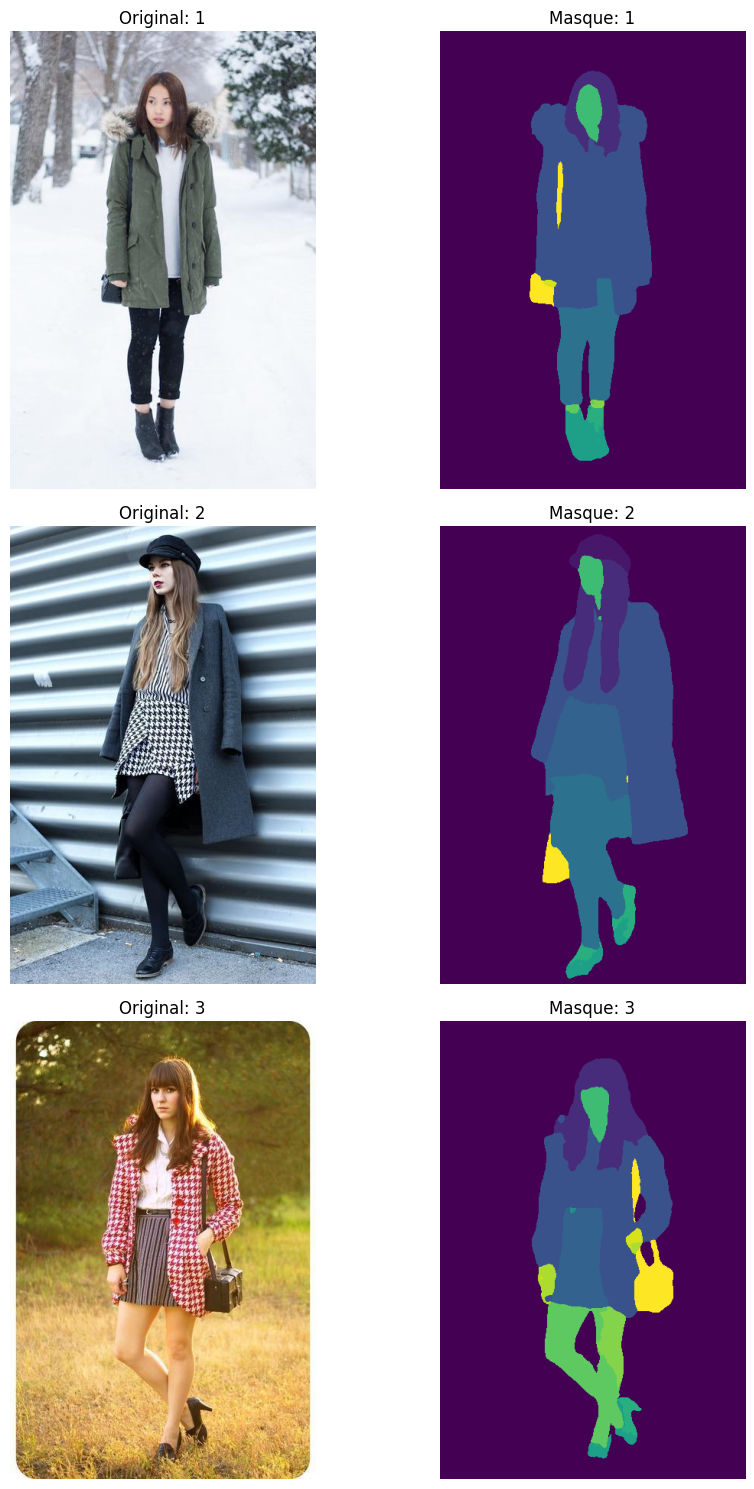

In [19]:
if __name__ == "__main__": # Pour s'assurer que c'est bien le fichier depuis lequel on a lancé le code
    image_paths = get_image_paths(IMAGE_DIR)

    # Si il n'y a pas d'images, quitter le programme.
    # 'get_image_paths' s'occupe déja d'afficher un message dans ce cas.
    if not image_paths:
        os.close(0)

    # Segmenter les images
    print("Traitement en batch des images...")
    batch_segmentation_results = segment_images_batch(image_paths)
    print("Traitement en batch terminé.")

    display_segmented_images_batch(image_paths, batch_segmentation_results)